```
Copyright 2026 Google LLC

Licensed under the Apache License, Version 2.0 (the "License");
you may not use this file except in compliance with the License.
You may obtain a copy of the License at

    https://www.apache.org/licenses/LICENSE-2.0

Unless required by applicable law or agreed to in writing, software
distributed under the License is distributed on an "AS IS" BASIS,
WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
See the License for the specific language governing permissions and
limitations under the License.
```

In [ ]:
from IPython.display import display
from io import StringIO
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [ ]:
# Use styling that is consistent with empirical analysis
entropy_lines = {
    'Shannon': '-',
    'Normalized': ':',
    #'Tsallis': '-.',
}

In [ ]:
csv_data_string = """Header,Panopticlick,AmIUnique,browser fingerprinting,Hiding in the crowd,Your speaker or my snooper?,Fashion Faux Pas,How Unique is Whose Browser?
Publication date,2010,2016,2017,2018,2022,2023,2025
n,470161,118934,3615,2067942,2093,1848,8400
User agent Shannon entropy,10.0,9.779,7.234,7.150,6.466,4.449,4.613
User agent Normalized entropy,0.531,0.570,0.612,0.341,0.586,0.41,0.354
"""
pub_data_table = pd.read_csv(StringIO(csv_data_string)).set_index("Header")
pub_data_table

,Panopticlick,AmIUnique,browser fingerprinting,Hiding in the crowd,Your speaker or my snooper?,Fashion Faux Pas,How Unique is Whose Browser?
Header,,,,,,,
Publication date,2010.000,2016.000,2017.000,2018.000,2022.000,2023.000,2025.000
n,470161.000,118934.000,3615.000,2067942.000,2093.000,1848.000,8400.000
User agent Shannon entropy,10.000,9.779,7.234,7.150,6.466,4.449,4.613
User agent Normalized entropy,0.531,0.570,0.612,0.341,0.586,0.410,0.354


The cell below generates the data for **Table 1** of the paper: *User agent entropy published in prior work, ordered by publication date.*

In [ ]:
df = pub_data_table.transpose()
df['Publication date'] = df['Publication date'].astype(int)
df['n'] = df['n'].astype(int)
df

Header,Publication date,n,User agent Shannon entropy,User agent Normalized entropy
Panopticlick,2010,470161,10.000,0.531
AmIUnique,2016,118934,9.779,0.570
browser fingerprinting,2017,3615,7.234,0.612
Hiding in the crowd,2018,2067942,7.150,0.341
Your speaker or my snooper?,2022,2093,6.466,0.586
Fashion Faux Pas,2023,1848,4.449,0.410
How Unique is Whose Browser?,2025,8400,4.613,0.354


The cell below generates **Figure 4** of the paper: *Shannon and normalized entropy reported in prior papers, by publication date.*

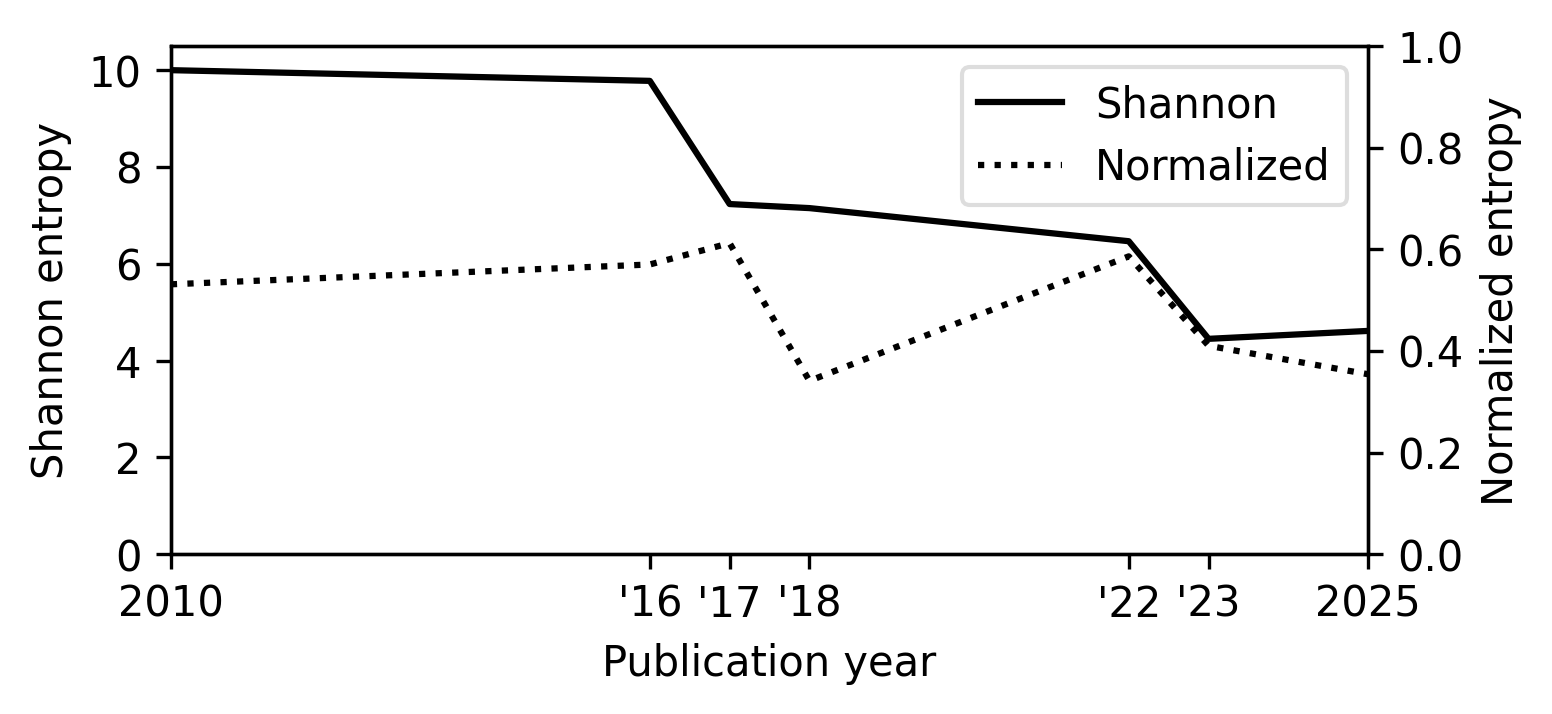

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(5.15,2.2), dpi=300)

lns = ax.plot(df['Publication date'], df['User agent Shannon entropy'], entropy_lines['Shannon'], label='Shannon', color='black')
ax.set_ylabel('Shannon entropy')
ax.set_ylim(0, 10.5)
ax.set_xticks(df['Publication date'])
ax.set_xticklabels(['2010', "'16", "'17", "'18", "'22", "'23", "2025"])
ax.set_xlim(2010, 2025)
ax2 = ax.twinx()
ax2.set_ylabel('Normalized entropy')
ax2.set_ylim(0, 1)
ax2.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1])
lns += ax2.plot(df['Publication date'], df['User agent Normalized entropy'], entropy_lines['Normalized'], label='Normalized', color='black')
ax.set_xlabel('Publication year')

labs = [l.get_label() for l in lns]
_ = plt.legend(lns, labs, facecolor='white', framealpha=0.65)